In [1]:
from pyspark.sql import SparkSession
from pathlib import Path
import pandas as pd
import math
from pyspark.sql.types import DoubleType, IntegerType, FloatType, LongType, DecimalType
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import trim
import pyspark.sql.functions as F
from pyspark.sql.types import (
    StringType,
    BooleanType,
    IntegerType,
    LongType,
    DoubleType,
    FloatType,
)

spark = (
    SparkSession.builder.appName("Data-Pipeline")
    .config("spark.driver.memory", "6g")
    .config("spark.sql.shuffle.partitions", "16")
    .getOrCreate()
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/23 09:09:08 WARN Utils: Your hostname, Evelyn-Nguyen.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.9 instead (on interface en0)
26/09/23 09:09:08 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/opt/homebrew/opt/apache-spark/libexec/python/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/23 09:09:09 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/23 09:09:10 WARN Utils: Service 'SparkUI' could not 

In [2]:
ROOT = next(
    (
        p
        for p in [Path.cwd(), *Path.cwd().parents]
        if ((p / "src").is_dir() and (p / "notebooks").is_dir())
    ),
    Path.cwd(),
)

RAW_DIR = ROOT / "data" / "raw"

unsw = (
    spark.read.option("header", True)
    .option("inferSchema", True)
    .csv(str(RAW_DIR / "UNSW-NB15.csv"))
)


In [3]:
def clean_and_deduplicate_col(df):

    seen = set()
    new_columns = []

    for col in df.columns:
        if col == "fwd_header_length.1":
            clean_col = "fwd_header_length"
        else:
            clean_col = col.strip().lower().replace(" ", "_").replace(".", "_").replace("/", "_")

        final_col = clean_col
        i = 1
        while final_col in seen:
            final_col = f"{clean_col}_{i}"
            i += 1

        seen.add(final_col)
        new_columns.append(final_col)

    return df.toDF(*new_columns)

In [4]:
print("=UNSW=")
unsw = clean_and_deduplicate_col(unsw)
print("Rows:", unsw.count())
print("Columns:", len(unsw.columns))

unsw.show(5, truncate=False)

=UNSW=
Rows: 2540047
Columns: 49
+----------+-----+-------------+------+-----+-----+--------+------+------+----+----+-----+-----+-------+-----------+-----------+-----+-----+----+----+-----+-----+-------+-------+-----------+-----------+-------+---------+----------+----------+-------+--------+------+------+------+---------------+------------+----------------+------------+----------+----------+----------+----------+-----------+----------------+----------------+--------------+----------+-----+
|srcip     |sport|dstip        |dsport|proto|state|dur     |sbytes|dbytes|sttl|dttl|sloss|dloss|service|sload      |dload      |spkts|dpkts|swin|dwin|stcpb|dtcpb|smeansz|dmeansz|trans_depth|res_bdy_len|sjit   |djit     |stime     |ltime     |sintpkt|dintpkt |tcprtt|synack|ackdat|is_sm_ips_ports|ct_state_ttl|ct_flw_http_mthd|is_ftp_login|ct_ftp_cmd|ct_srv_src|ct_srv_dst|ct_dst_ltm|ct_src__ltm|ct_src_dport_ltm|ct_dst_sport_ltm|ct_dst_src_ltm|attack_cat|label|
+----------+-----+-------------+------+----

26/09/23 09:09:16 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [5]:
count_before_unsw = unsw.count()
unsw = unsw.dropDuplicates()


count_after_unsw = unsw.count()
duplicates_removed_unsw = count_before_unsw - count_after_unsw

print(f"Số dòng ban đầu: {count_before_unsw}")
print(f"Số dòng sau khi làm sạch: {count_after_unsw}")
print(f"Đã xóa {duplicates_removed_unsw} dòng trùng lặp.")


Số dòng ban đầu: 2540047
Số dòng sau khi làm sạch: 2059414
Đã xóa 480633 dòng trùng lặp.


In [6]:
def display_missing_value(df):
    total_rows = df.count()

    null_counts = (
        df.select(
            [
                F.sum(F.when(F.col(f"`{c}`").isNull(), 1).otherwise(0)).alias(c)
                for c in df.columns
            ]
        )
        .collect()[0]
        .asDict()
    )

    result_data = []
    for col_name, count in null_counts.items():
        if count > 0:
            percentage = round((count / total_rows) * 100, 2)
            result_data.append((col_name, count, percentage))

    if not result_data:
        print("Không có giá trị Missing nào trong DataFrame!")
    else:
        stats_df = spark.createDataFrame(
            result_data,
            schema=["Column_Name", "Missing_Count", "Missing_Percentage(%)"],
        )
        print(f"Tổng số dòng: {total_rows}")
        stats_df.show(truncate=False)

missing value in 3 cols: ct_flw_http_mthd, is_ftp_login,attack_cat

In [7]:
print("=UNSW MISSING STATISTICS=")
display_missing_value(unsw)

=UNSW MISSING STATISTICS=


Tổng số dòng: 2059414
+----------------+-------------+---------------------+
|Column_Name     |Missing_Count|Missing_Percentage(%)|
+----------------+-------------+---------------------+
|ct_flw_http_mthd|933603       |45.33                |
|is_ftp_login    |1014165      |49.25                |
|attack_cat      |1959771      |95.16                |
+----------------+-------------+---------------------+



In [8]:
# 1. Điền số 0 cho toàn bộ giá trị Missing (Null) ở cả 2 cột
unsw = unsw.fillna(0, subset=["ct_flw_http_mthd", "is_ftp_login"])

# 2. Đưa các giá trị bất thường (2, 4...) của is_ftp_login về 1
unsw = unsw.withColumn(
    "is_ftp_login",
    F.when(F.col("is_ftp_login") > 1, 1).otherwise(F.col("is_ftp_login")),
)

# Kiểm tra lại xem 2 cột này còn giá trị Null nào không
unsw.select(
    [
        F.sum(F.col(c).isNull().cast("int")).alias(c)
        for c in ["ct_flw_http_mthd", "is_ftp_login"]
    ]
).show()

+----------------+------------+
|ct_flw_http_mthd|is_ftp_login|
+----------------+------------+
|               0|           0|
+----------------+------------+



In [9]:
unsw.groupBy("service").count().orderBy(F.col("count").desc()).show()

+--------+-------+
| service|  count|
+--------+-------+
|       -|1169177|
|     dns| 386755|
|    http| 203531|
|ftp-data| 124849|
|    smtp|  81132|
|     ssh|  46981|
|     ftp|  45074|
|    pop3|   1490|
|     ssl|    142|
|    snmp|    113|
|    dhcp|    102|
|  radius|     37|
|     irc|     31|
+--------+-------+



In [10]:
unsw = unsw.withColumn(
    "service", F.when(F.col("service") == "-", "unknown").otherwise(F.col("service"))
)
unsw.groupBy("service").count().orderBy(F.col("count").desc()).show()

+--------+-------+
| service|  count|
+--------+-------+
| unknown|1169177|
|     dns| 386755|
|    http| 203531|
|ftp-data| 124849|
|    smtp|  81132|
|     ssh|  46981|
|     ftp|  45074|
|    pop3|   1490|
|     ssl|    142|
|    snmp|    113|
|    dhcp|    102|
|  radius|     37|
|     irc|     31|
+--------+-------+



In [11]:
unsw = unsw.withColumn(
    "attack_cat",
    F.when(F.col("label") == 0, "Normal")
     .when(F.col("attack_cat").isNull() | (F.trim(F.col("attack_cat")) == ""), "Normal")
     .otherwise(F.trim(F.col("attack_cat")))
)

unsw.groupBy("attack_cat").count().orderBy(F.col("count").desc()).show(truncate=False)

+--------------+-------+
|attack_cat    |count  |
+--------------+-------+
|Normal        |1959771|
|Exploits      |27599  |
|Generic       |25378  |
|Fuzzers       |21795  |
|Reconnaissance|13357  |
|DoS           |5665   |
|Analysis      |2184   |
|Backdoor      |1684   |
|Shellcode     |1511   |
|Backdoors     |299    |
|Worms         |171    |
+--------------+-------+



In [12]:
unsw = unsw.withColumn(
    "ct_ftp_cmd", 
    F.when(F.trim(F.col("ct_ftp_cmd")) == "", 0)
     .otherwise(F.col("ct_ftp_cmd"))
     .cast("int") # Dùng chuỗi định danh chuẩn của PySpark
)

In [13]:
columns_to_drop = ["srcip", "dstip", "sport", "dsport"]   
existing_cols_to_drop = [c for c in columns_to_drop if c in unsw.columns]
unsw = unsw.drop(*existing_cols_to_drop)
print(f"Đã xóa các định danh tĩnh: {existing_cols_to_drop}")

Đã xóa các định danh tĩnh: ['srcip', 'dstip', 'sport', 'dsport']


In [14]:
# 1. Tách các cột String/Boolean (chắc chắn là Categorical) và các cột dạng Số
string_cols = [
    f.name
    for f in unsw.schema.fields
    if isinstance(f.dataType, (StringType, BooleanType))
]
numeric_cols = [
    f.name
    for f in unsw.schema.fields
    if isinstance(f.dataType, (IntegerType, LongType, DoubleType, FloatType))
]

distinct_counts = (
    unsw.agg(*[F.approx_count_distinct(F.col(c)).alias(c) for c in numeric_cols])
    .collect()[0]
    .asDict()
)

discrete_numeric_cols = []
continuous_numeric_cols = []

THRESHOLD = 50

for col_name, unique_count in distinct_counts.items():
    if unique_count <= THRESHOLD:
        discrete_numeric_cols.append(col_name)
    else:
        continuous_numeric_cols.append(col_name)  # Đây là các cột sẽ bị bỏ qua khi đếm

# 3. Gộp cột String và cột Số rời rạc thành danh sách phân loại cuối cùng
final_categorical_cols = string_cols + discrete_numeric_cols

print(
    f"Bỏ qua {len(continuous_numeric_cols)} cột số liên tục: {continuous_numeric_cols[:5]}..."
)
print(f"Tìm thấy {len(final_categorical_cols)} cột Categorical/Rời rạc để đếm.")
print("-" * 50)

# 4. Vòng lặp đếm giá trị và xuất kết quả cho từng cột Categorical
for col_name in final_categorical_cols:
    print(f"=== Tần suất giá trị của cột: {col_name} ===")

    # Chỉ lấy top 10 giá trị xuất hiện nhiều nhất để tránh trôi màn hình
    unsw.groupBy(col_name).count().orderBy(F.col("count").desc()).show(
        10, truncate=False
    )

26/09/23 09:09:41 WARN DAGScheduler: Broadcasting large task binary with size 1053.6 KiB


Bỏ qua 30 cột số liên tục: ['dur', 'sbytes', 'dbytes', 'sloss', 'dloss']...
Tìm thấy 15 cột Categorical/Rời rạc để đếm.
--------------------------------------------------
=== Tần suất giá trị của cột: proto ===


+-----+-------+
|proto|count  |
+-----+-------+
|tcp  |1448858|
|udp  |588026 |
|arp  |6658   |
|unas |4765   |
|ospf |3964   |
|icmp |498    |
|sctp |444    |
|any  |138    |
|gre  |95     |
|rsvp |92     |
+-----+-------+
only showing top 10 rows
=== Tần suất giá trị của cột: state ===


+-----+-------+
|state|count  |
+-----+-------+
|FIN  |1433507|
|CON  |543297 |
|INT  |75336  |
|REQ  |6050   |
|RST  |525    |
|ECO  |313    |
|CLO  |160    |
|URH  |108    |
|ACC  |41     |
|PAR  |30     |
+-----+-------+
only showing top 10 rows
=== Tần suất giá trị của cột: service ===


+--------+-------+
|service |count  |
+--------+-------+
|unknown |1169177|
|dns     |386755 |
|http    |203531 |
|ftp-data|124849 |
|smtp    |81132  |
|ssh     |46981  |
|ftp     |45074  |
|pop3    |1490   |
|ssl     |142    |
|snmp    |113    |
+--------+-------+
only showing top 10 rows
=== Tần suất giá trị của cột: attack_cat ===


...

+------------+-------+
|ct_state_ttl|count  |
+------------+-------+
|0           |1922129|
|1           |76134  |
|2           |54098  |
|3           |4071   |
|6           |2940   |
|4           |40     |
|5           |2      |
+------------+-------+

=== Tần suất giá trị của cột: ct_flw_http_mthd ===


+----------------+-------+
|ct_flw_http_mthd|count  |
+----------------+-------+
|0               |1860405|
|1               |187917 |
|6               |5020   |
|4               |4310   |
|3               |586    |
|2               |516    |
|5               |232    |
|14              |133    |
|9               |121    |
|12              |65     |
+----------------+-------+
only showing top 10 rows
=== Tần suất giá trị của cột: is_ftp_login ===


+------------+-------+
|is_ftp_login|count  |
+------------+-------+
|0           |2019730|
|1           |39684  |
+------------+-------+

=== Tần suất giá trị của cột: ct_ftp_cmd ===


+----------+-------+
|ct_ftp_cmd|count  |
+----------+-------+
|0         |2019643|
|1         |38853  |
|2         |263    |
|4         |250    |
|3         |206    |
|5         |105    |
|6         |91     |
|8         |3      |
+----------+-------+

=== Tần suất giá trị của cột: label ===


+-----+-------+
|label|count  |
+-----+-------+
|0    |1959771|
|1    |99643  |
+-----+-------+



/opt/homebrew/opt/apache-spark/libexec/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()



[2] Đang lấy mẫu 5% dữ liệu để vẽ biểu đồ...



[3] Bắt đầu vẽ 30 cột, chia làm 5 phần để giải phóng RAM...

--- Đang vẽ phần 1/5 (Các cột từ 0 đến 5) ---


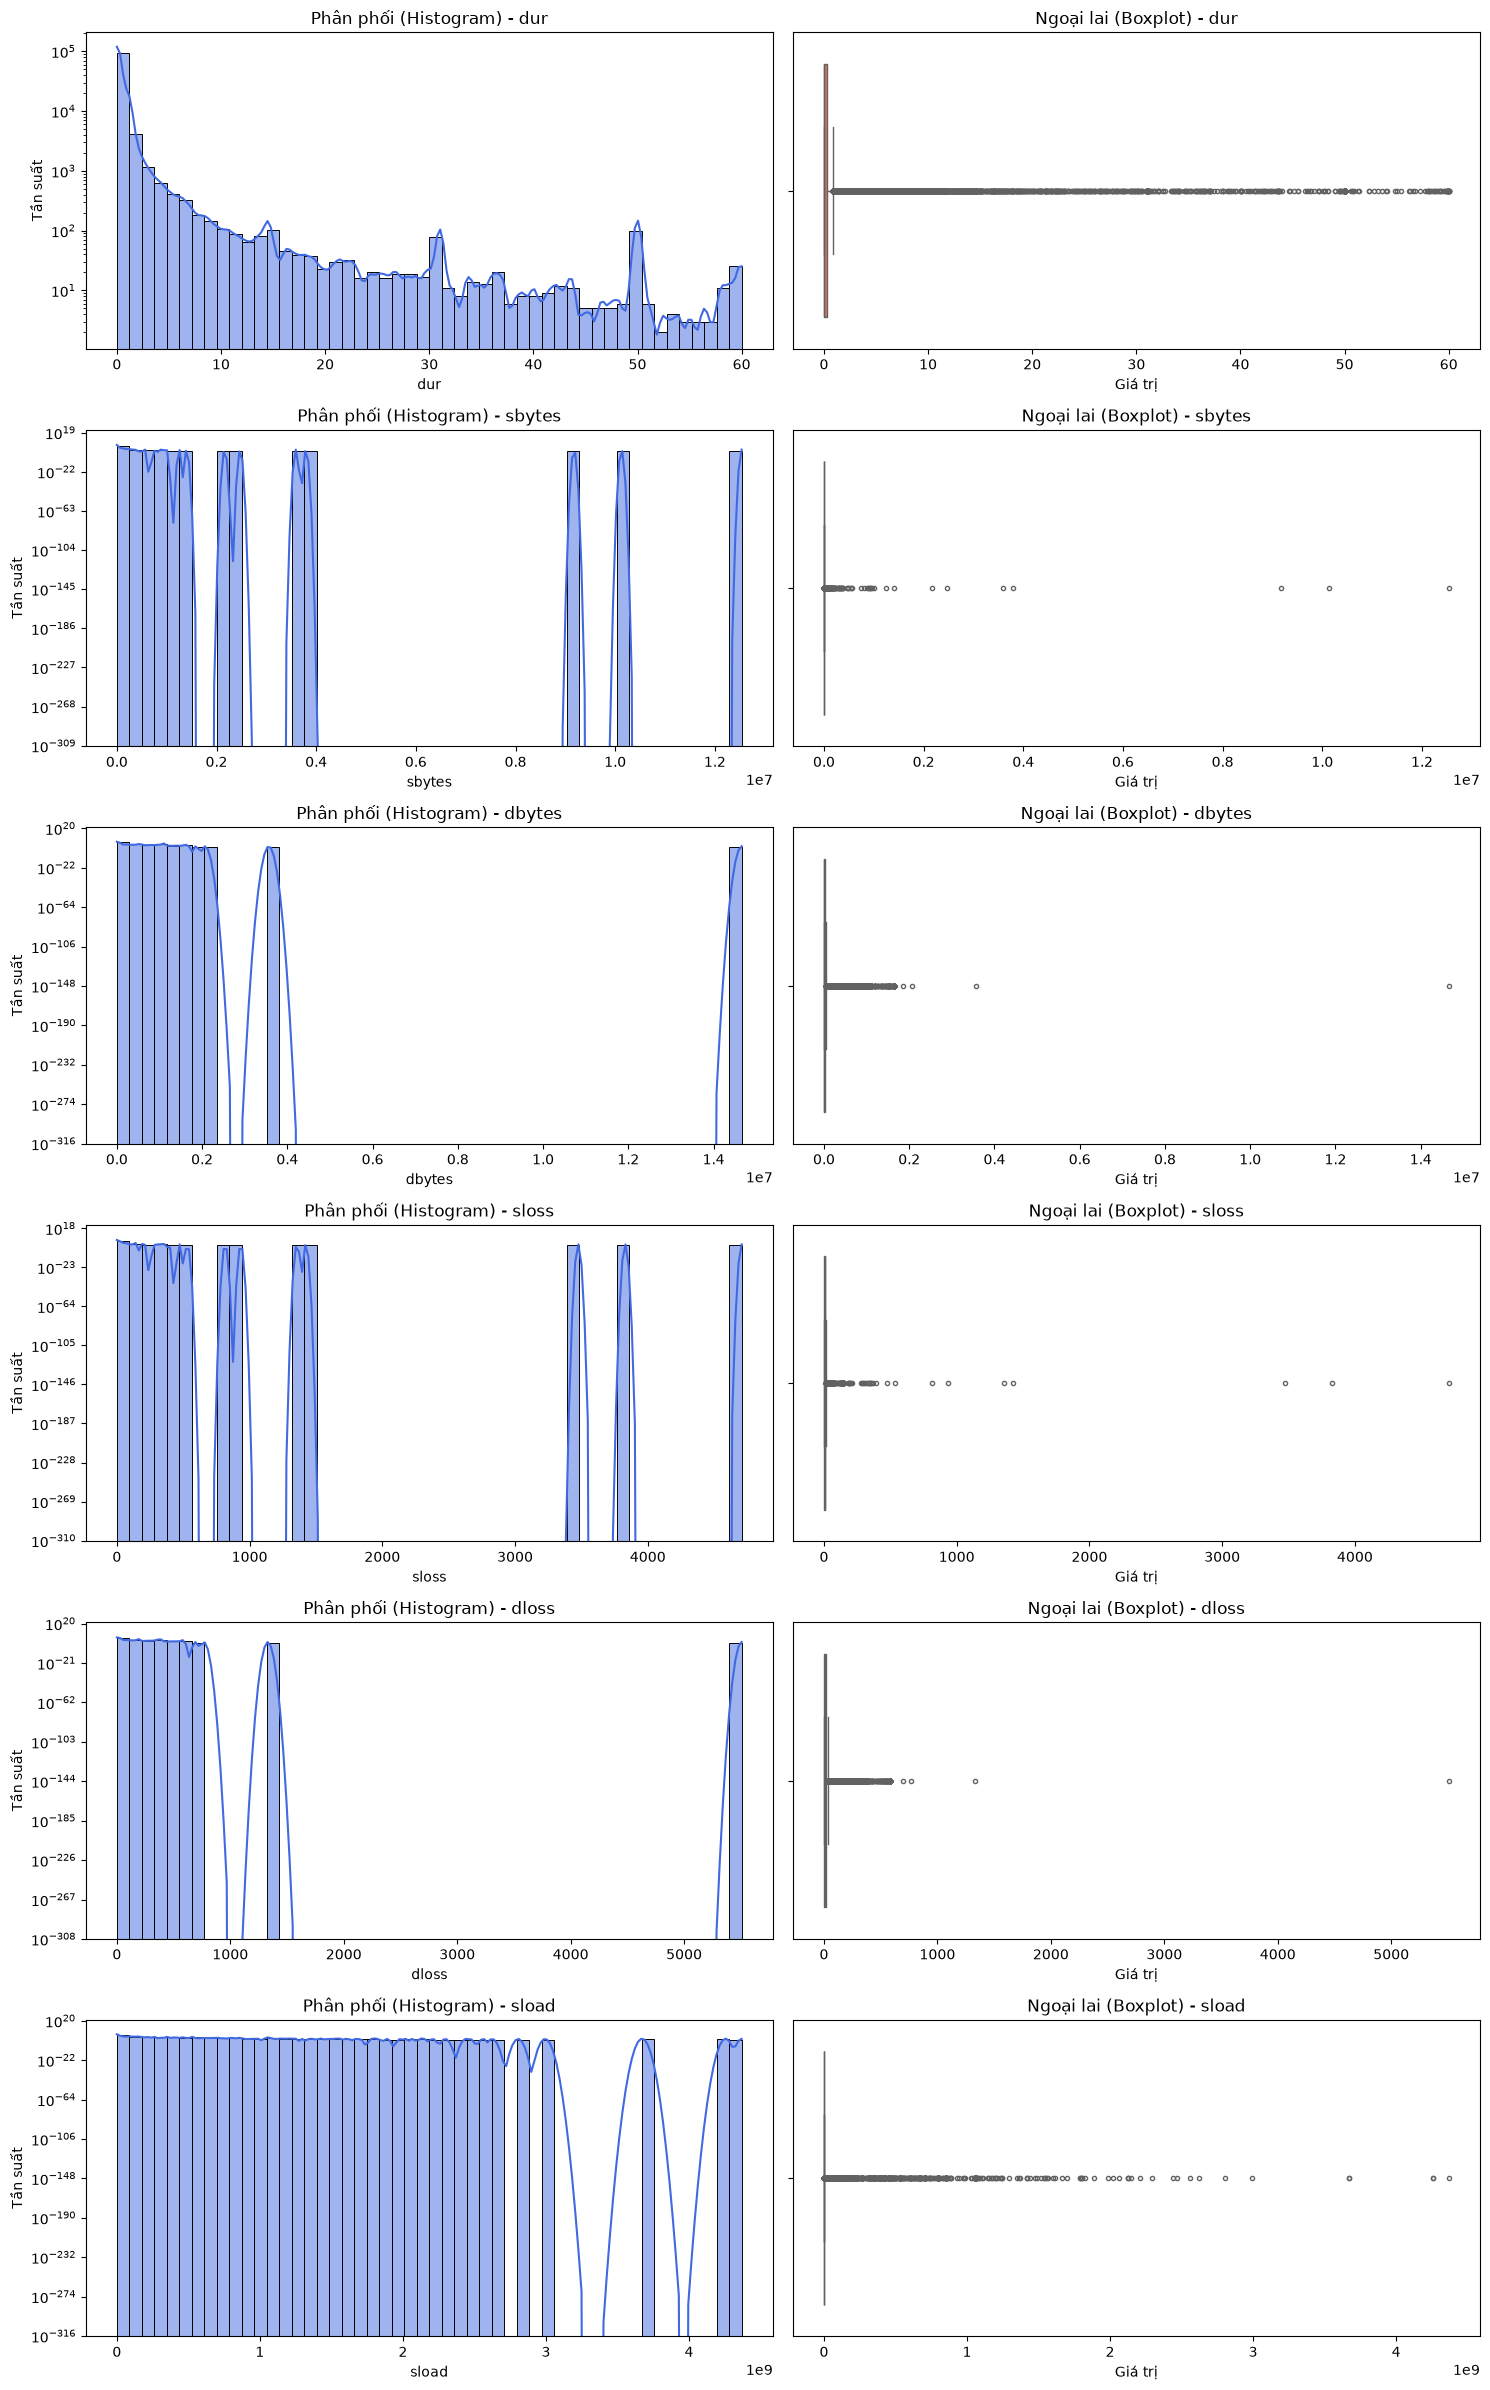


--- Đang vẽ phần 2/5 (Các cột từ 6 đến 11) ---


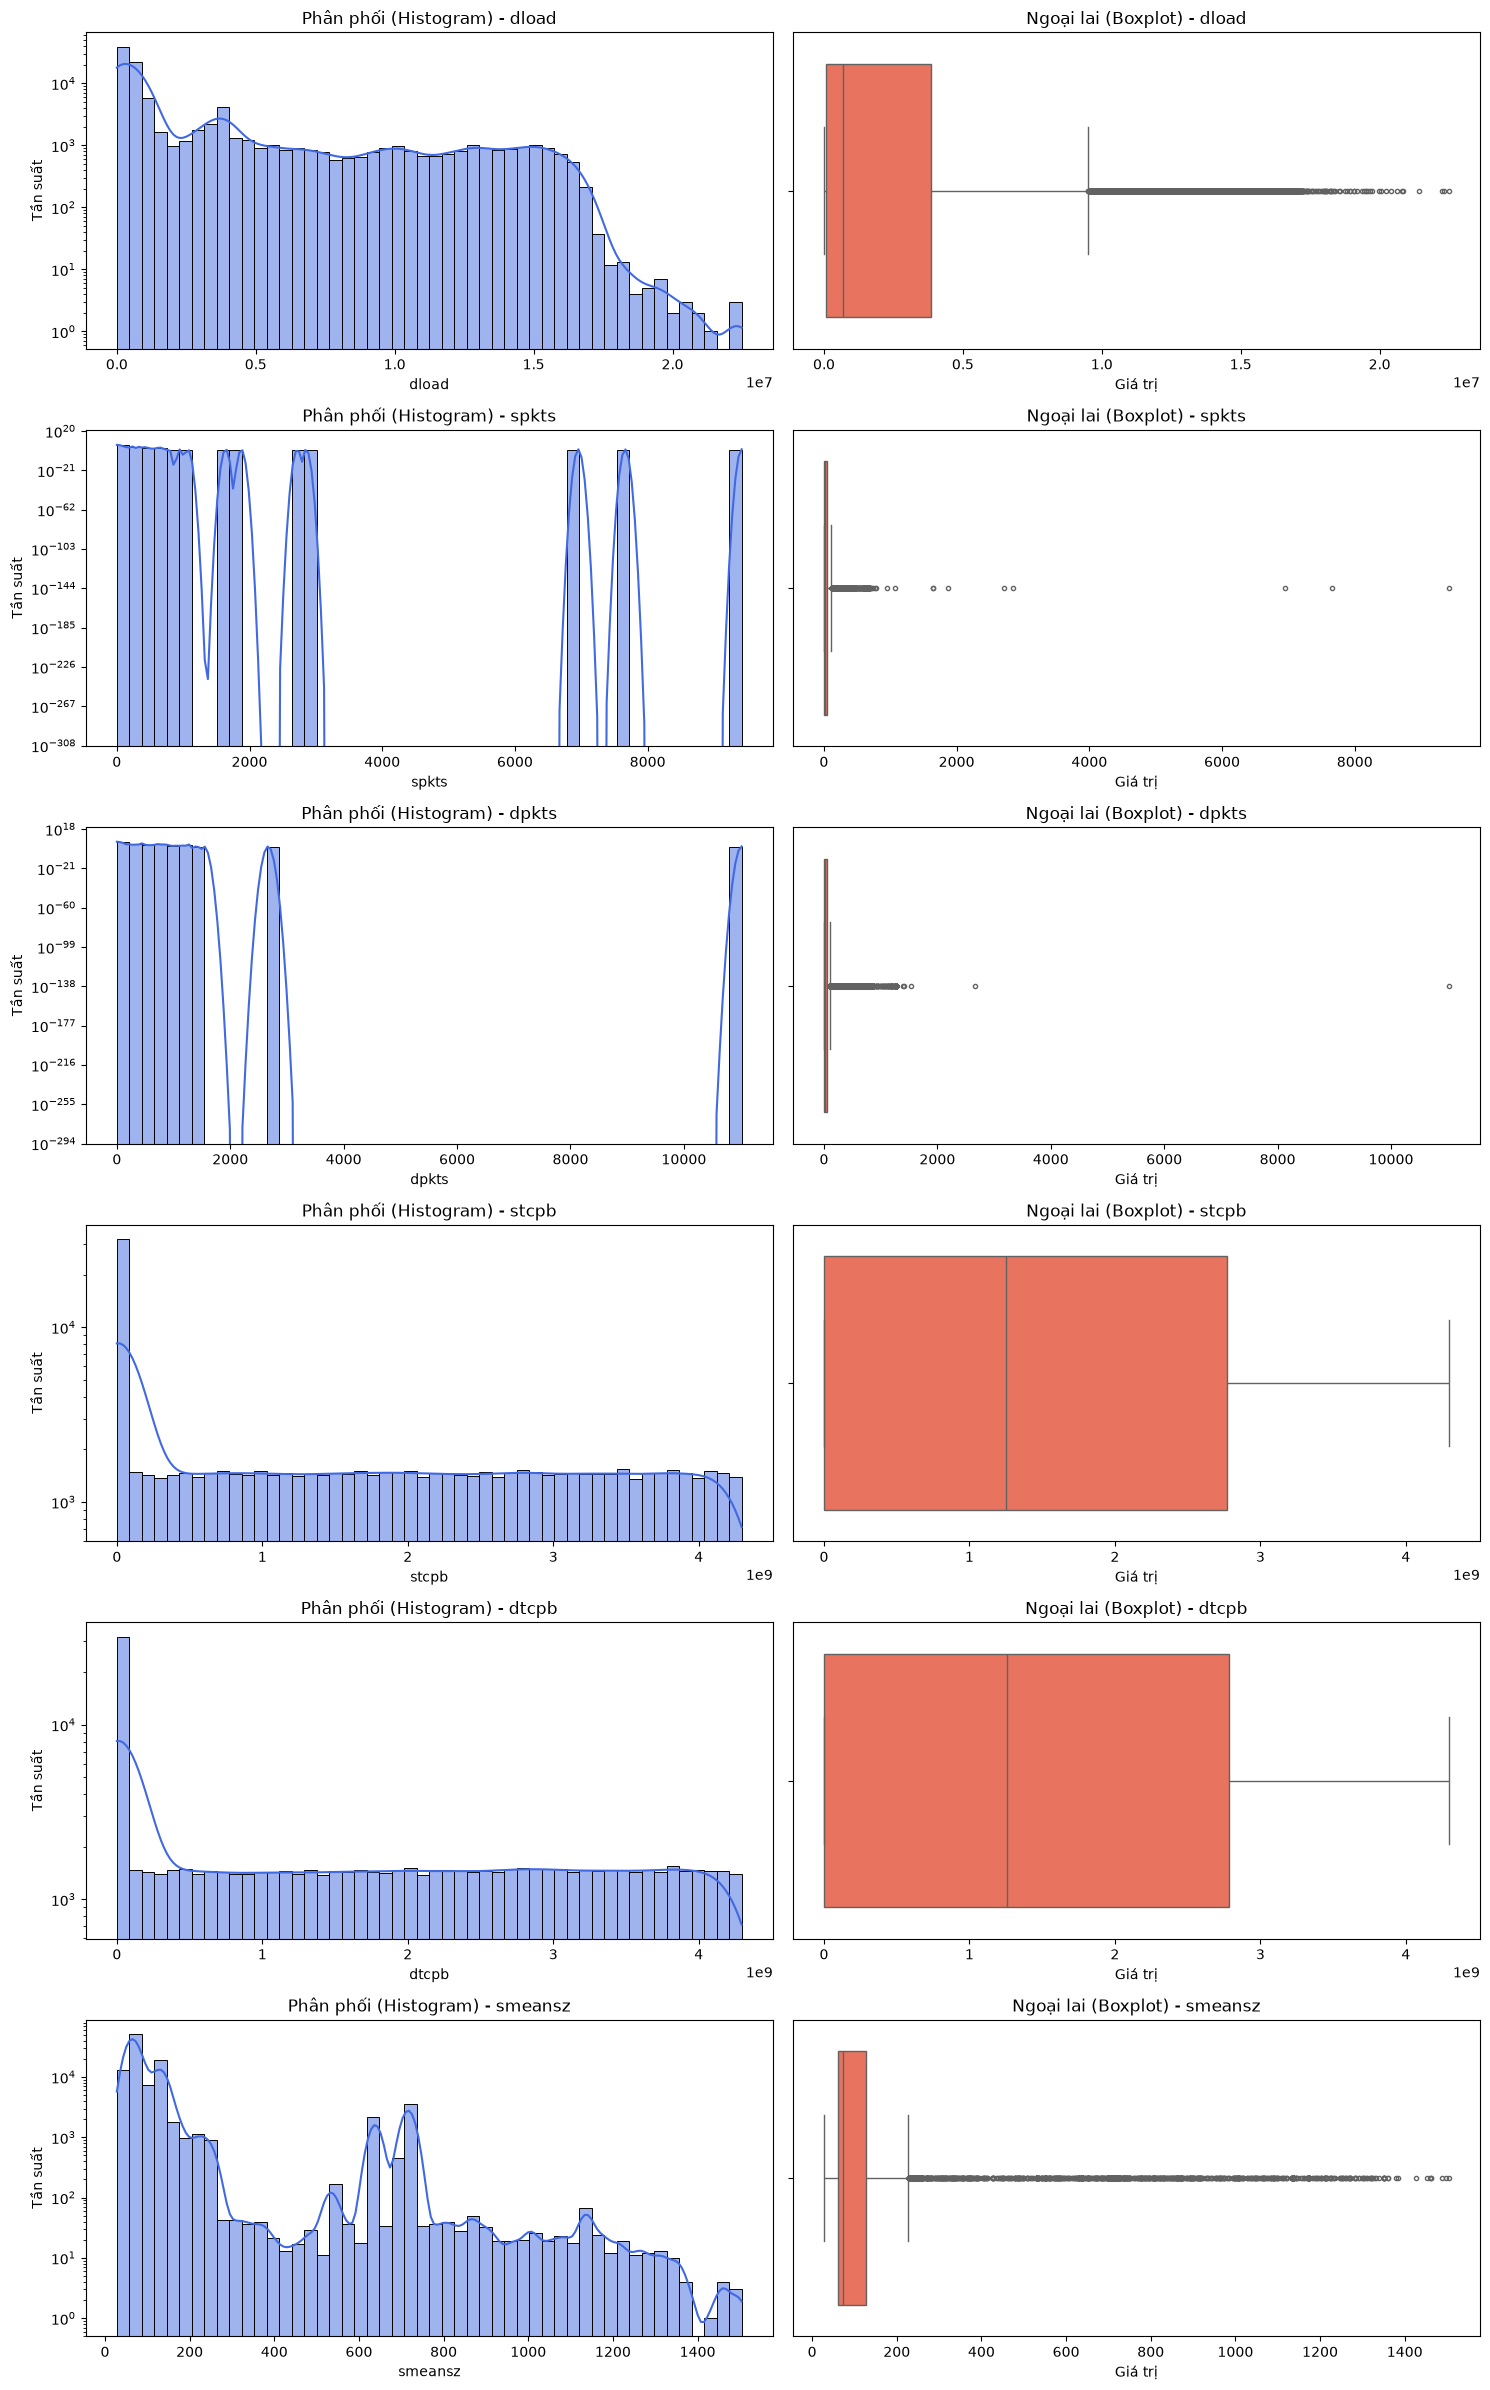


--- Đang vẽ phần 3/5 (Các cột từ 12 đến 17) ---


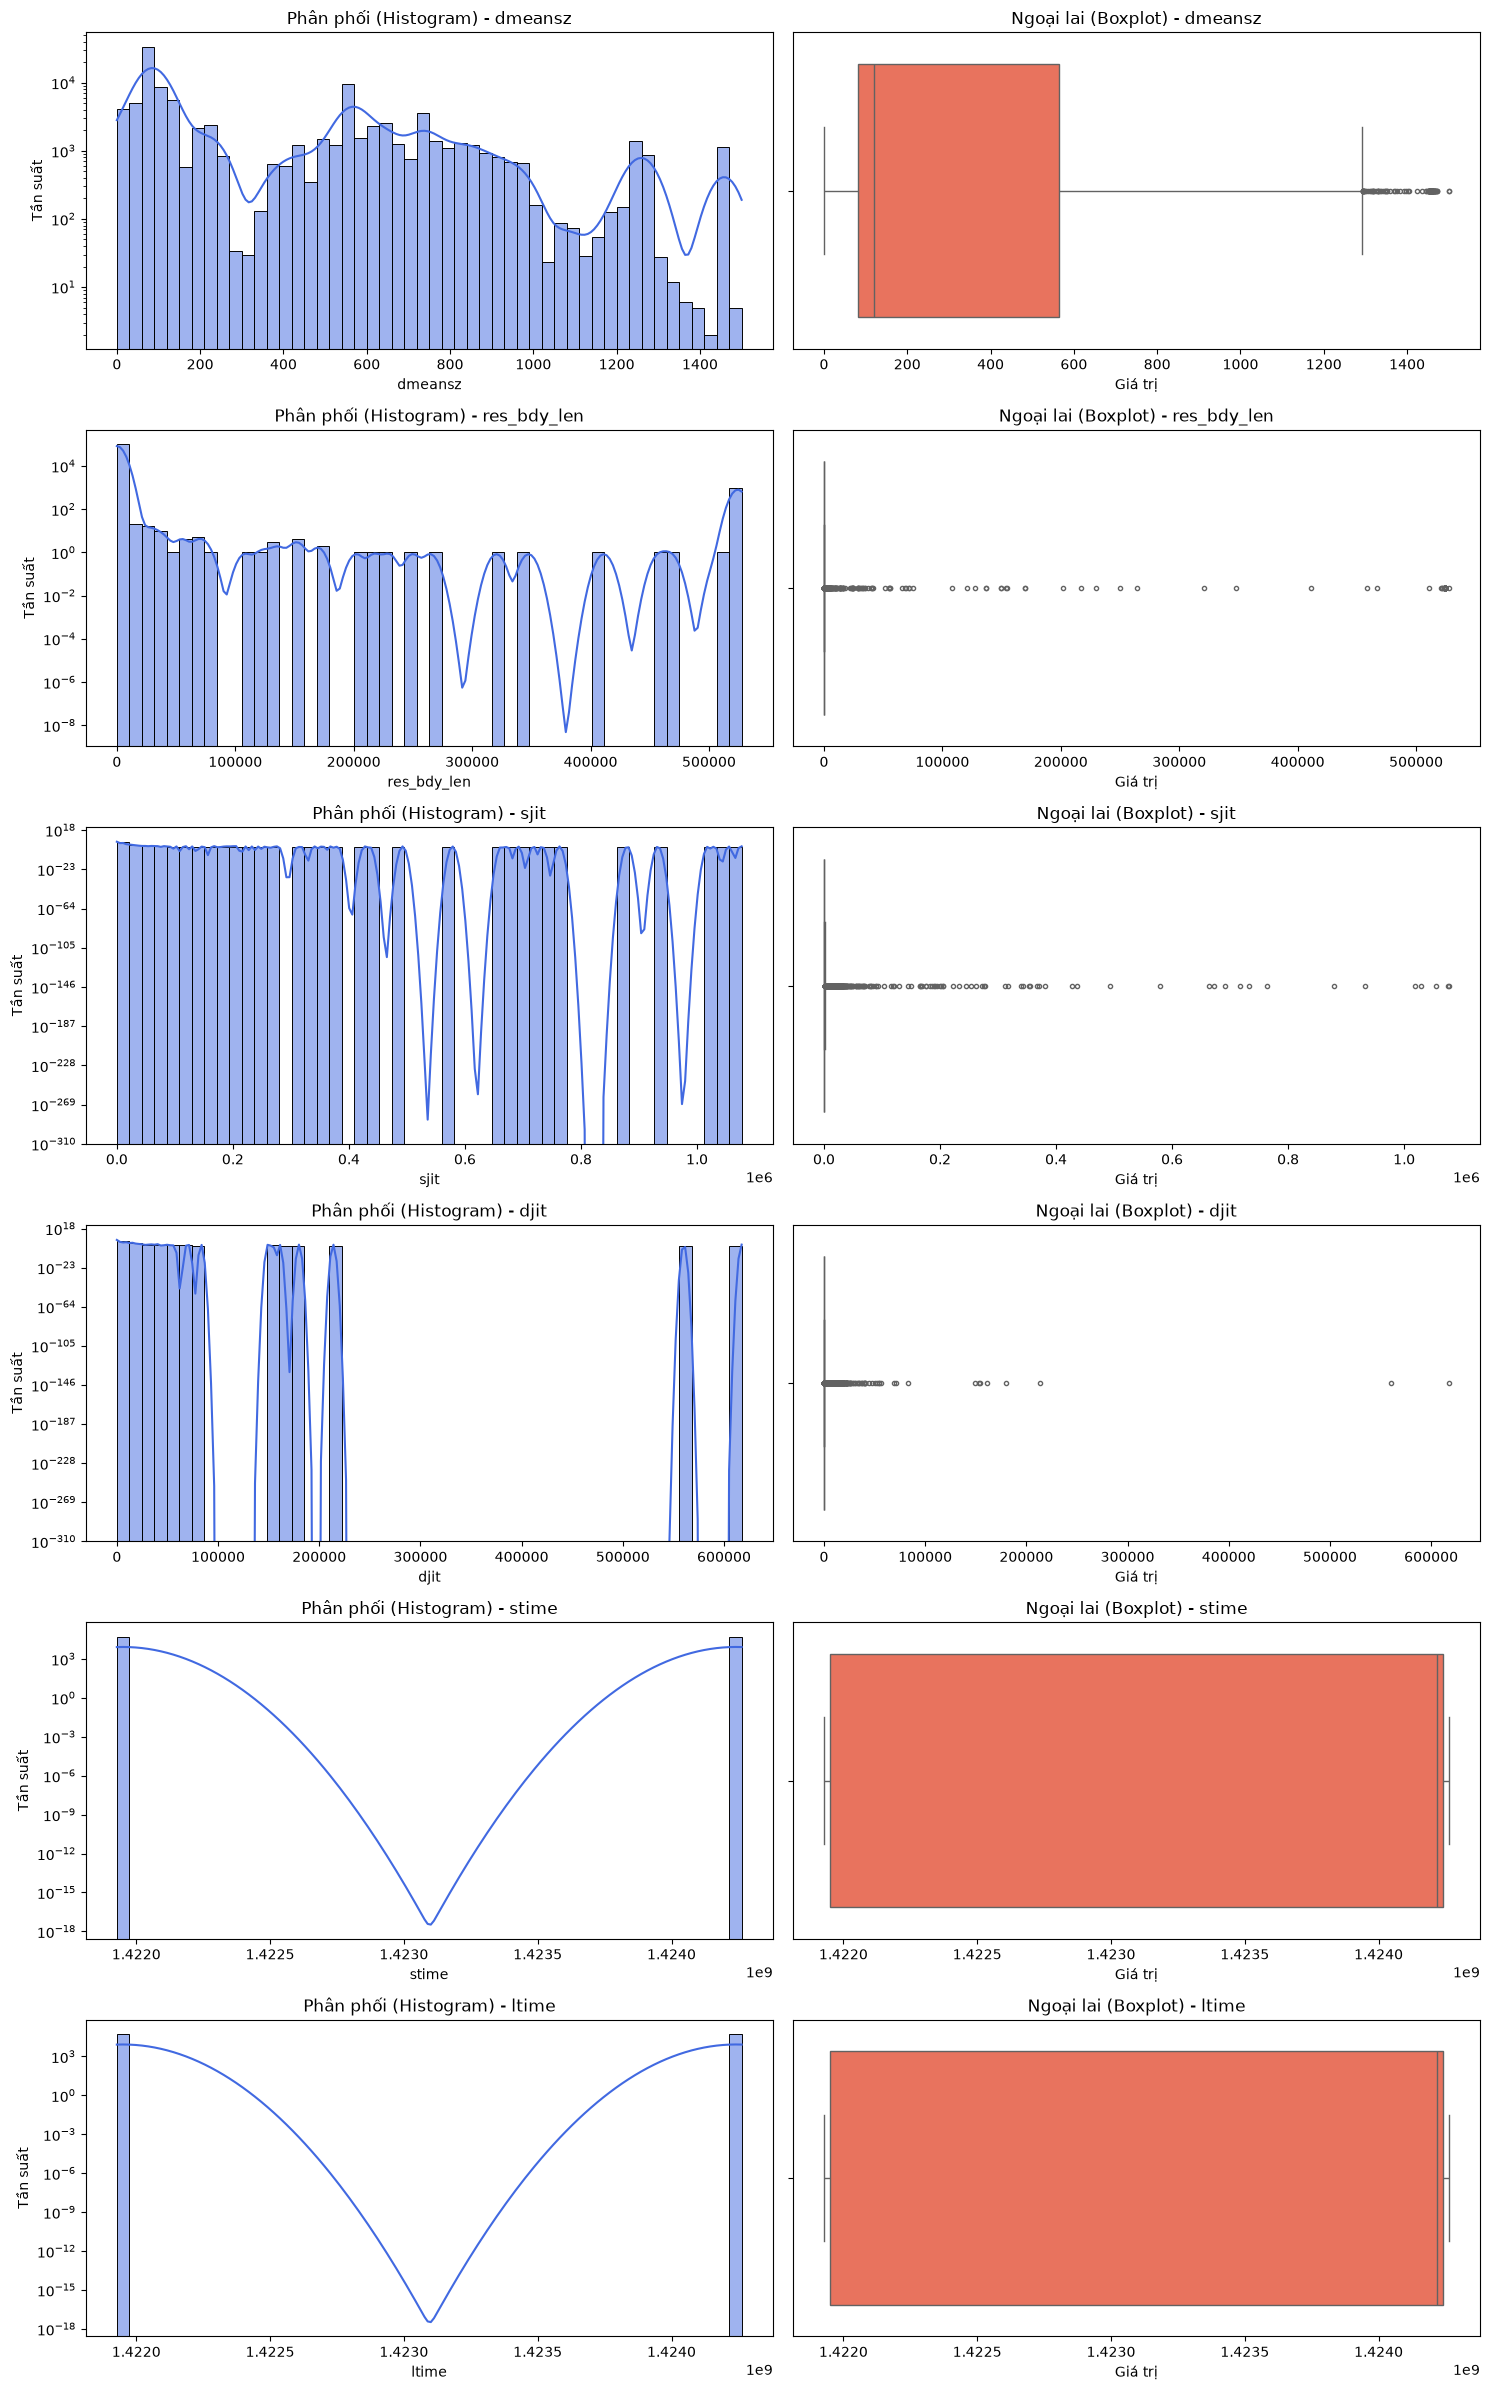


--- Đang vẽ phần 4/5 (Các cột từ 18 đến 23) ---


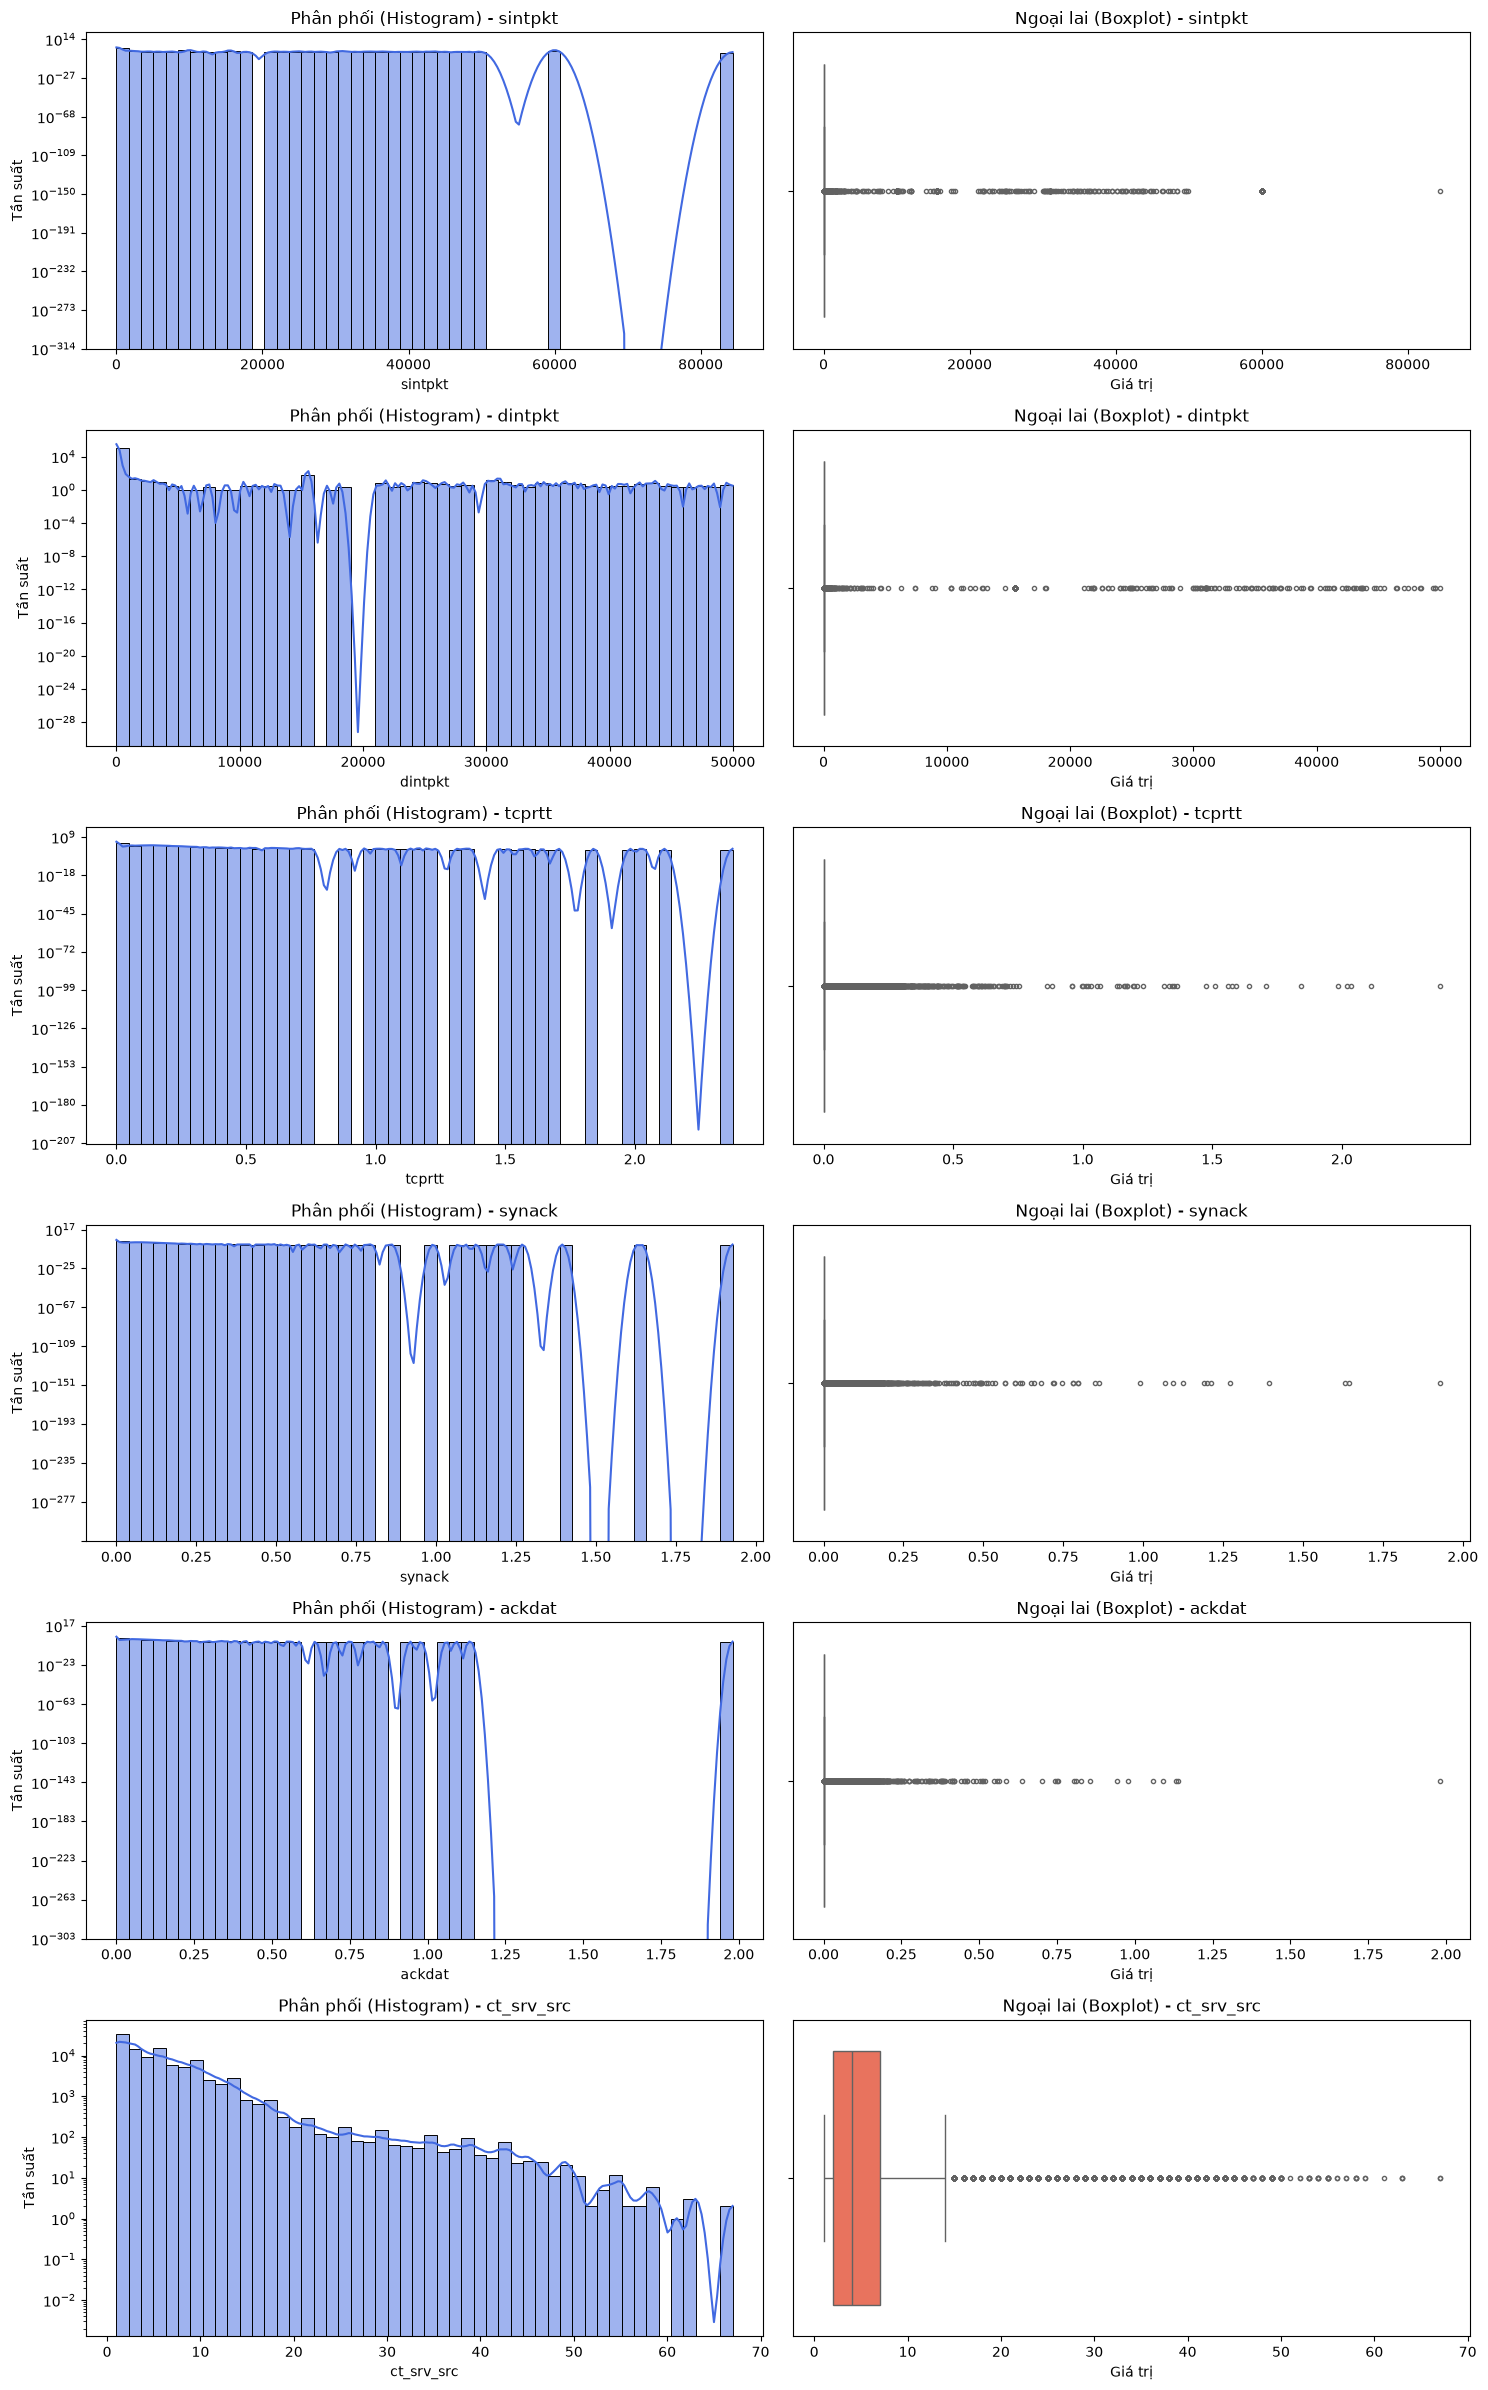


--- Đang vẽ phần 5/5 (Các cột từ 24 đến 29) ---


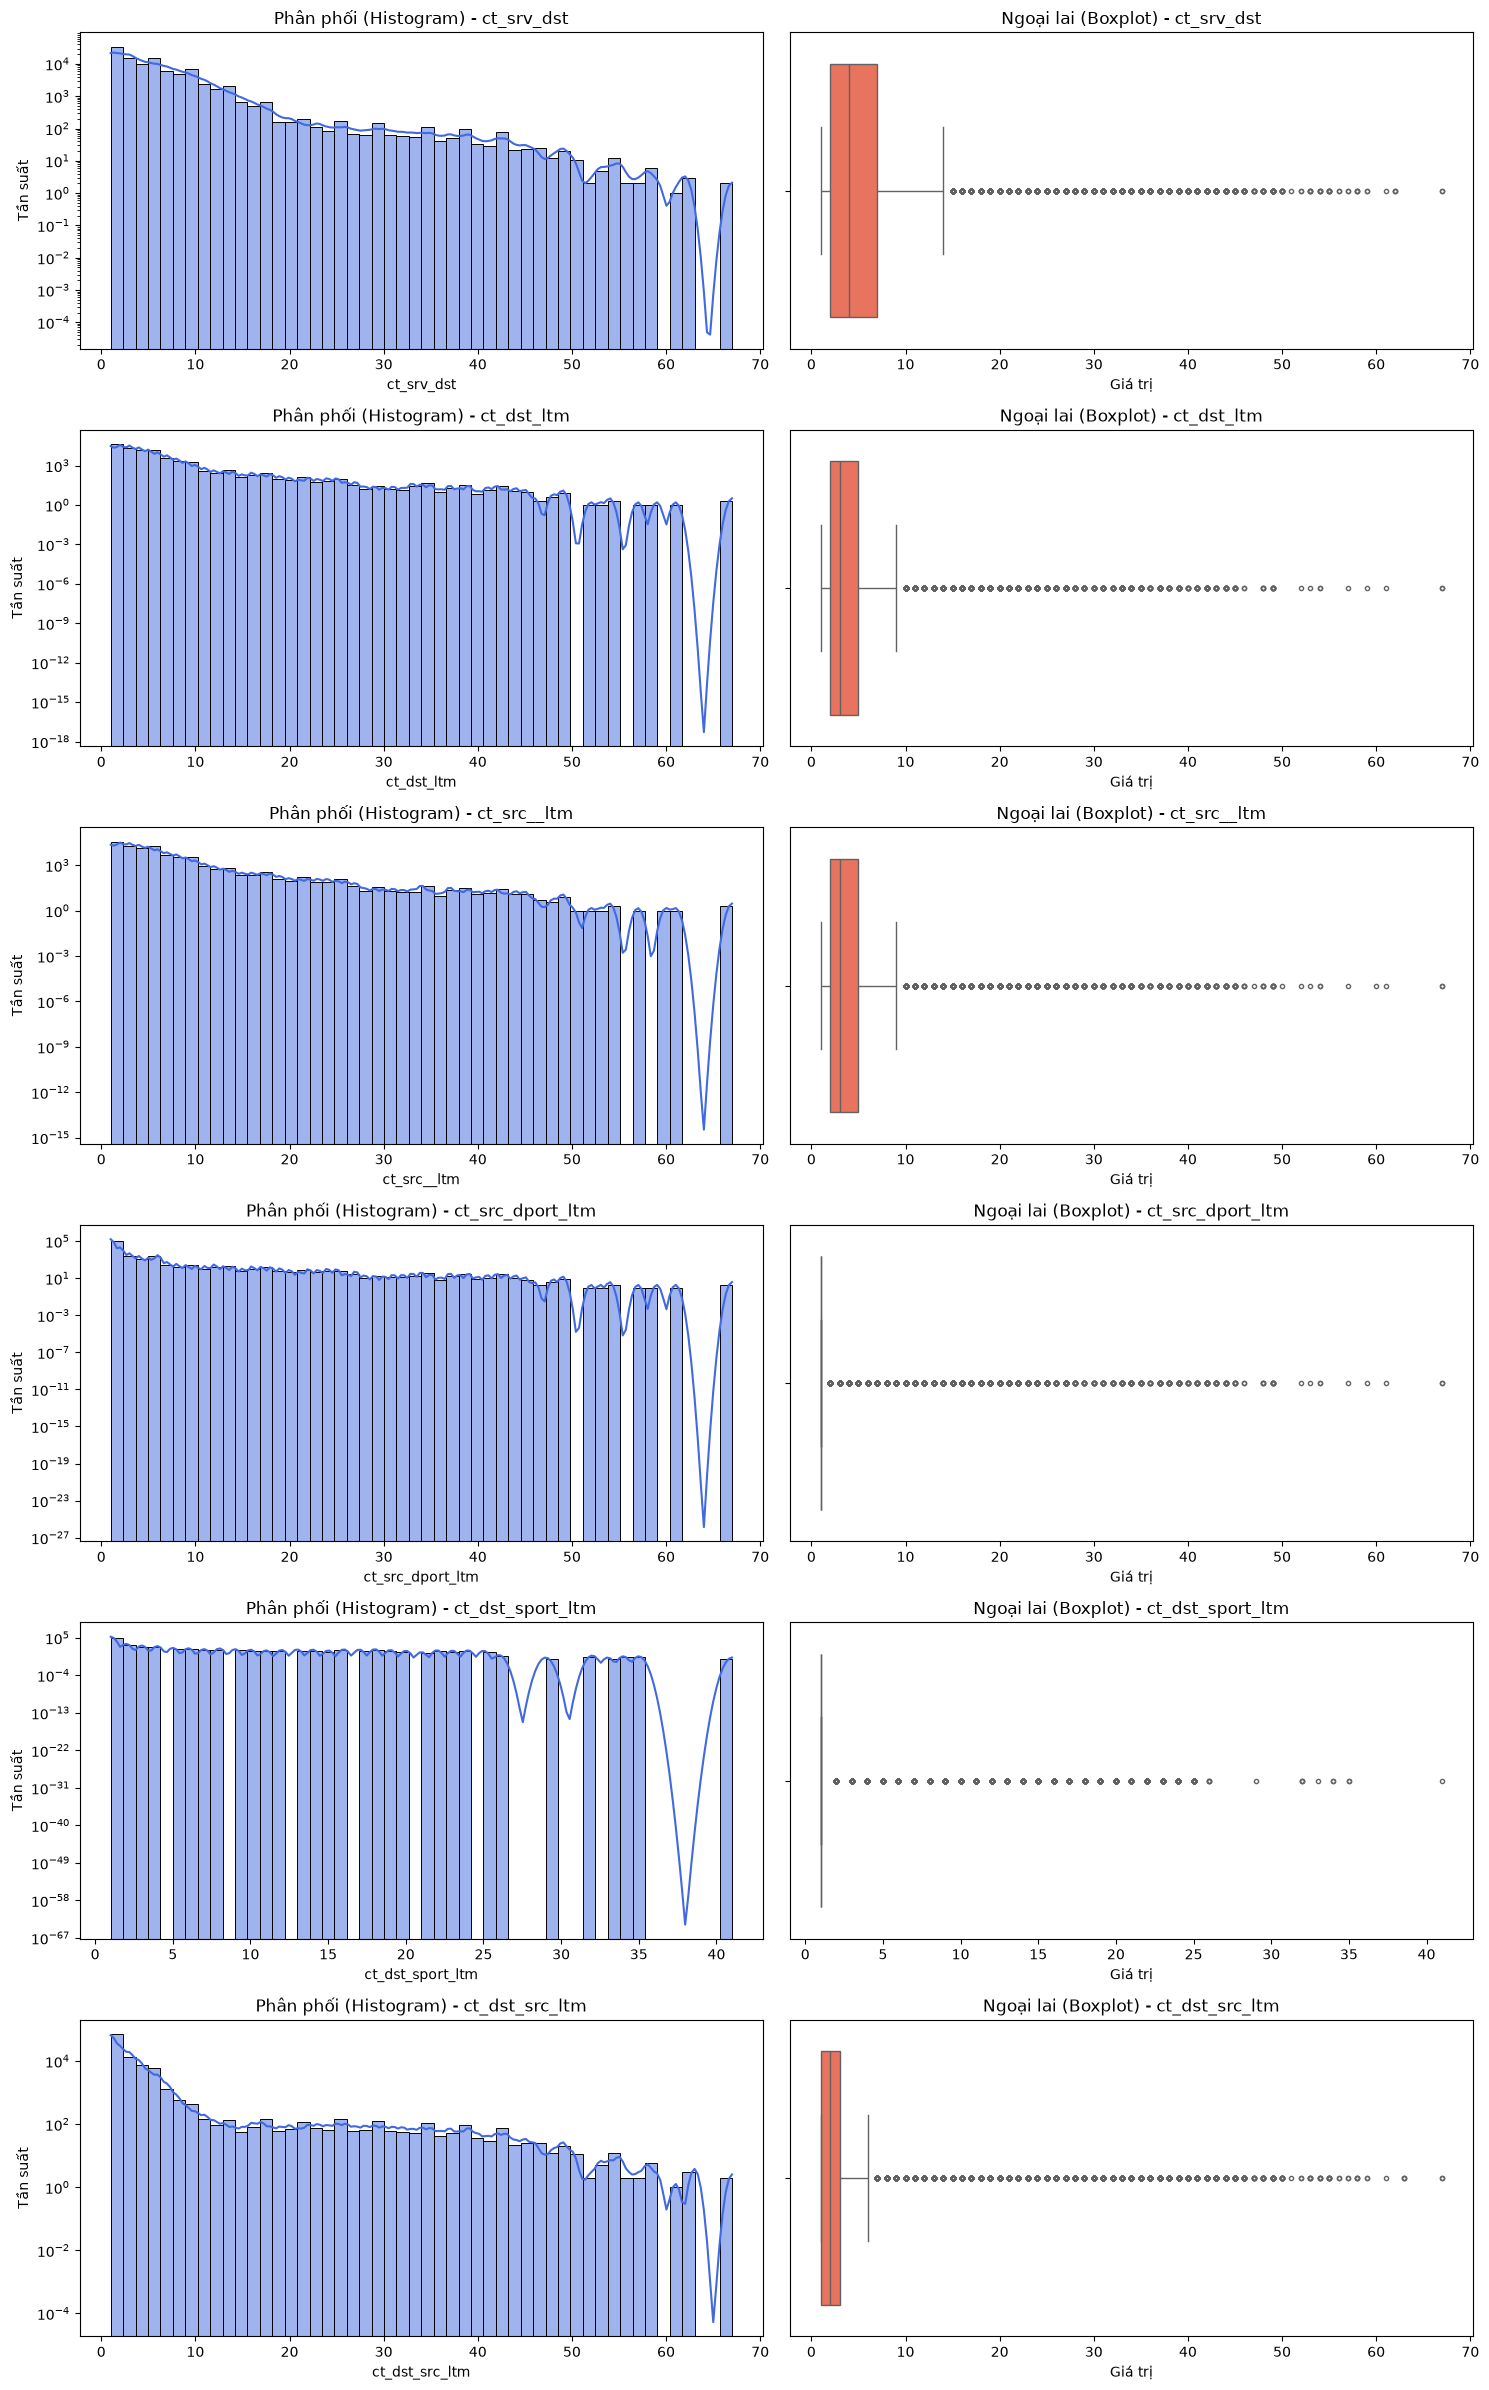


Hoàn tất quá trình vẽ!


In [15]:
print("\n[2] Đang lấy mẫu 5% dữ liệu để vẽ biểu đồ...")
df_numeric_sample = (
    unsw.select(continuous_numeric_cols)
    .sample(withReplacement=False, fraction=0.05, seed=42)
    .toPandas()
)

# --- CHIA NHỎ ĐỂ VẼ (BATCHING) ---
batch_size = 6  # Số lượng cột vẽ trong 1 lần (bạn có thể chỉnh sửa)
total_cols = len(continuous_numeric_cols)
num_batches = math.ceil(total_cols / batch_size)

print(f"\n[3] Bắt đầu vẽ {total_cols} cột, chia làm {num_batches} phần để giải phóng RAM...")

for batch_idx in range(num_batches):
    start_idx = batch_idx * batch_size
    end_idx = min(start_idx + batch_size, total_cols)
    
    # Lấy ra danh sách các cột cho batch hiện tại
    cols_to_plot = continuous_numeric_cols[start_idx:end_idx]
    
    print(f"\n--- Đang vẽ phần {batch_idx + 1}/{num_batches} (Các cột từ {start_idx} đến {end_idx - 1}) ---")
    
    # Thiết lập khung biểu đồ linh hoạt theo số cột của batch
    plt.figure(figsize=(15, 4 * len(cols_to_plot)))
    
    for i, col_name in enumerate(cols_to_plot):
        # Cột bên trái: Histogram (Xem phân phối)
        plt.subplot(len(cols_to_plot), 2, 2 * i + 1)
        sns.histplot(df_numeric_sample[col_name], bins=50, kde=True, color="royalblue")
        plt.title(f"Phân phối (Histogram) - {col_name}", fontsize=12)
        plt.ylabel("Tần suất")
        plt.yscale("log")

        # Cột bên phải: Boxplot (Tìm Outliers)
        plt.subplot(len(cols_to_plot), 2, 2 * i + 2)
        sns.boxplot(
            x=df_numeric_sample[col_name],
            color="tomato",
            flierprops={"marker": "o", "markersize": 3},
        )
        plt.title(f"Ngoại lai (Boxplot) - {col_name}", fontsize=12)
        plt.xlabel("Giá trị")

    plt.tight_layout()
    plt.show()
    
    plt.close('all')

print("\nHoàn tất quá trình vẽ!")

In [16]:
cols_to_remove = ["stime", "ltime","stcpb","dtcpb","synack","ackdat"]
unsw = unsw.drop(*cols_to_remove)

In [17]:
continuous_numeric_cols = [col for col in continuous_numeric_cols if col not in cols_to_remove]

In [18]:
import pyspark.sql.functions as F
import math

skewness_exprs = [F.skewness(F.col(c)).alias(c) for c in continuous_numeric_cols]

skewness_results = unsw.select(*skewness_exprs).collect()[0].asDict()

# 3. Lọc ra các cột có độ lệch lớn (Ngưỡng > 2 hoặc < -2)
SKEW_THRESHOLD = 2.0
highly_skewed_cols = []

for col_name, skew_val in skewness_results.items():
    # Bổ sung kiểm tra math.isnan để tránh lỗi toán học khi tính abs()
    if skew_val is not None and not math.isnan(skew_val):
        if abs(skew_val) > SKEW_THRESHOLD:
            highly_skewed_cols.append(col_name)

print(f"Tìm thấy {len(highly_skewed_cols)} cột có độ lệch cực đại ( > {SKEW_THRESHOLD} ).")
print(f"Danh sách các cột cần áp dụng Log Transformation:\n{highly_skewed_cols}")

Tìm thấy 22 cột có độ lệch cực đại ( > 2.0 ).
Danh sách các cột cần áp dụng Log Transformation:
['dur', 'sbytes', 'dbytes', 'sloss', 'dloss', 'sload', 'spkts', 'dpkts', 'smeansz', 'res_bdy_len', 'sjit', 'djit', 'sintpkt', 'dintpkt', 'tcprtt', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src__ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm']


In [20]:
for col in highly_skewed_cols:
    train_data = train_data.withColumn(col, F.log1p(F.col(col)))
    test_data = test_data.withColumn(col, F.log1p(F.col(col)))

In [21]:
# 1. Khai báo thủ công các nhóm cột đặc thù và nhãn (Target)
categorical_cols = ["proto", "service", "state"]
binary_cols = ["is_sm_ips_ports", "is_ftp_login"]
target_cols = ["attack_cat", "label"]

# 2. Lấy ra tất cả các cột số (Integer, Double, Float) từ schema của PySpark
# Bước này giúp loại bỏ các cột String bị sót (nếu có)
all_numeric_cols = [
    col_name for col_name, data_type in train_data.dtypes 
    if data_type in ['int', 'double', 'float', 'bigint']
]

# 3. Trích xuất các cột số liên tục (Continuous) bằng cách loại trừ
continuous_numeric_cols = [
    col for col in all_numeric_cols 
    if col not in binary_cols + target_cols
]

# (Tùy chọn) Bổ sung lệnh xóa các cột vô ích đã phân tích trước đó
cols_to_remove = ["stime", "ltime", "stcpb", "dtcpb", "synack", "ackdat"]
continuous_numeric_cols = [
    col for col in continuous_numeric_cols 
    if col not in cols_to_remove
]

# 4. In báo cáo kiểm tra kết quả
print("=== BÁO CÁO PHÂN LOẠI CỘT ĐẶC TRƯNG ===")
print(f"[1] Phân loại (Categorical) - {len(categorical_cols)} cột: {categorical_cols}")
print(f"[2] Nhị phân (Binary)       - {len(binary_cols)} cột: {binary_cols}")
print(f"[3] Số liên tục (Continuous)- {len(continuous_numeric_cols)} cột")
print(f"[4] Nhãn dự đoán (Target)   - {len(target_cols)} cột: {target_cols}")

# Hiển thị thử 5 cột số liên tục đầu tiên
print(f"\nDanh sách 5 cột Continuous Numeric đầu tiên: {continuous_numeric_cols[:5]}")

=== BÁO CÁO PHÂN LOẠI CỘT ĐẶC TRƯNG ===
[1] Phân loại (Categorical) - 3 cột: ['proto', 'service', 'state']
[2] Nhị phân (Binary)       - 2 cột: ['is_sm_ips_ports', 'is_ftp_login']
[3] Số liên tục (Continuous)- 32 cột
[4] Nhãn dự đoán (Target)   - 2 cột: ['attack_cat', 'label']

Danh sách 5 cột Continuous Numeric đầu tiên: ['dur', 'sbytes', 'dbytes', 'sttl', 'dttl']


In [22]:
parquet_path = '/Users/thonph/Desktop/KLTN/data/processed/clean_unsw.parquet'

In [23]:
unsw.write.mode("overwrite").parquet(parquet_path)

In [24]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

indexers = [
    StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") 
    for c in categorical_cols
]

encoders = [
    OneHotEncoder(inputCol=c+"_idx", outputCol=c+"_ohe") 
    for c in categorical_cols
]

assembler_inputs = [c+"_ohe" for c in categorical_cols] + binary_cols + continuous_numeric_cols
unsw_assembler = VectorAssembler(
    inputCols=assembler_inputs, 
    outputCol="unscaled_features",
    handleInvalid="keep"
)

unsw_scaler = StandardScaler(
    inputCol="unscaled_features", 
    outputCol="scaled_features", 
    withMean=True, # Bắt buộc True cho MLP (Zero-mean)
    withStd=True
)

In [25]:
spark.stop()